## Experiment Setup
Configure model/persona and base directories for personalization comparison.


In [20]:
from pathlib import Path
import json
import warnings
from typing import List

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

# Configurable parameters
BASE_SCORE_DIR = "<PROJECT_ROOT>/Desktop/Desktop - ADUAED19365LPMX/Agent_IX_Personalization/gorilla/berkeley-function-call-leaderboard/LLM_as_judge_score"
MODEL_NAME = "gemini_3_flash_FC"  # Set to your desired model

# claude_opus_4_5_20251101_FC
# claude_sonnet_4_5_20250929_FC
# gemini_3_flash_FC
# gpt_4_1_2025_04_14_FC
# kimi_k2_0905_preview_FC

JUDGE_NAMES = [
    "anthropic_claude-opus-4.5",
    "anthropic_claude-sonnet-4.5",
    "google_gemini-3-flash-preview",
    "moonshotai_kimi-k2-0905"
]



# Auto-enumerate persona names to avoid omissions
import os
PERSONAS = [
    "chain_parallel",
    "chain_sequential",
    "confirmation_batch",
    "disambiguation_gradual",
    "disambiguation_upfront",
    "each_confirmation",
    "error_discovery_brief",
    "error_discovery_detail",
    "error_retry_escalation",
    "error_retry_silent",
    "info_collect_gradual",
    "info_collect_upfront",
    "param_high",
    "param_low",
    "param_medium",
    "presentation_compact",
    "presentation_layered",
    "silent",
    "source_high",
    "source_low",
    "tool_abortion_continue",
    "tool_abortion_stop",
    "tool_high",
    "tool_initiative_proactive",
    "tool_initiative_reactive",
    "tool_invocation_multiple",
    "tool_invocation_single",
    "tool_low",
    "tool_medium",
    "tool_switch_high_agency",
    "tool_switch_low_agency"
]

# Also adjust the directory check section:
for judge_name in JUDGE_NAMES:
    for persona in PERSONAS:
        no_personalization_dir = Path(BASE_SCORE_DIR) / judge_name / MODEL_NAME / "no_personalization" / persona
        personalization_dir = Path(BASE_SCORE_DIR) / judge_name / MODEL_NAME / "personalization" / persona
        # If the directory doesn't exist, skip without raising an error
        for p in [no_personalization_dir, personalization_dir]:
            if not p.exists():
                warnings.warn(f"Skip missing directory: {p}", UserWarning)
                continue
            if not any(p.iterdir()):
                warnings.warn(f"Directory exists but is empty, skipping: {p}", UserWarning)
                continue

# Fixed dimensions in judge output
DIMENSIONS: List[str] = [
    "initiative_timing",
    "interaction_coherence",
    "intent_alignment_drift",
    "interaction_preference_alignment",
    "commitment_consistency",
    "interaction_efficiency",
    "user_cognitive_load_trajectory",
    "overall_user_experience",
]

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

## Data Loading
Load judge JSON outputs (fixed 7 dimensions) for personalization vs. no_personalization.


In [21]:
def load_scores(directory: Path, persona: str = None) -> pd.DataFrame:
    files = sorted(directory.glob("*_judge.json"))
    if not files:
        raise FileNotFoundError(f"No *_judge.json files found in {directory}")
    rows = []
    for fp in files:
        try:
            content = json.loads(fp.read_text(encoding="utf-8"))
        except json.JSONDecodeError as exc:
            warnings.warn(f"Failed to parse JSON for {fp.name}: {exc}")
            continue

        # Compatible with multiple schemas
        parsed = content.get("parsed")
        if isinstance(parsed, dict) and parsed.get("dimensions"):
            # New format: content["parsed"]["dimensions"]
            dims_block = parsed.get("dimensions") or {}
        else:
            # Fallback 1: top-level "dimensions"
            dims_block = content.get("dimensions") or {}

            # Fallback 2: legacy format with single dimension/score
            if not dims_block:
                dim_name = content.get("dimension")
                score_val = content.get("score")
                if dim_name in DIMENSIONS and isinstance(score_val, (int, float)):
                    dims_block = {
                        dim_name: {
                            "score": float(score_val),
                            # Include other fields if present (optional)
                            "justification": content.get("justification", ""),
                            "evidence_turn_ids": content.get("evidence_turn_ids", []),
                        }
                    }
                else:
                    dims_block = {}

        row = {"test_id": fp.stem.replace("_judge", "")}
        if persona:
            row["persona"] = persona  # Add persona column for tracking
        
        for dim in DIMENSIONS:
            dim_entry = dims_block.get(dim)
            score = None if dim_entry is None else dim_entry.get("score")
            if isinstance(score, (int, float)):
                row[dim] = float(score)
            else:
                warnings.warn(
                    f"Missing/invalid score for '{dim}' in {fp.name}; set NaN"
                )
                row[dim] = np.nan
        rows.append(row)

    if not rows:
        raise ValueError(f"No valid records loaded from {directory}")
    columns = ["test_id"] + (["persona"] if persona else []) + DIMENSIONS
    return pd.DataFrame(rows, columns=columns)

In [22]:
# Directory/empty-dir checks already done in (1-87); only load and concat here, no extra warnings or existence checks
# Use a dict to store data for multiple judge models

no_personalization_data = {}
personalization_data = {}

for judge_name in JUDGE_NAMES:
    no_personalization_dfs = []
    personalization_dfs = []

    for persona in PERSONAS:
        no_personalization_dir = Path(BASE_SCORE_DIR) / judge_name / MODEL_NAME / "no_personalization" / persona
        personalization_dir = Path(BASE_SCORE_DIR) / judge_name / MODEL_NAME / "personalization" / persona

        try:
            no_df = load_scores(no_personalization_dir, persona=persona)
            no_personalization_dfs.append(no_df)
        except Exception:
            pass

        try:
            personalization_df = load_scores(personalization_dir, persona=persona)
            personalization_dfs.append(personalization_df)
        except Exception:
            pass

    if no_personalization_dfs:
        no_personalization_data[judge_name] = pd.concat(no_personalization_dfs, ignore_index=True)
    else:
        warnings.warn(f"No valid no_personalization data found for {judge_name}")

    if personalization_dfs:
        personalization_data[judge_name] = pd.concat(personalization_dfs, ignore_index=True)
    else:
        warnings.warn(f"No valid personalization data found for {judge_name}")

print(f"Loaded data for {len(no_personalization_data)} judge models: {list(no_personalization_data.keys())}")

/var/folders/h0/hg82lwhs2l1bvq786x_jh8xh0000gs/T/ipykernel_66724/660769016.py:48: UserWarning: Missing/invalid score for 'commitment_consistency' in multi_turn_long_context_138_judge.json; set NaN
  warnings.warn(
/var/folders/h0/hg82lwhs2l1bvq786x_jh8xh0000gs/T/ipykernel_66724/660769016.py:48: UserWarning: Missing/invalid score for 'initiative_timing' in multi_turn_long_context_101_judge.json; set NaN
  warnings.warn(
/var/folders/h0/hg82lwhs2l1bvq786x_jh8xh0000gs/T/ipykernel_66724/660769016.py:48: UserWarning: Missing/invalid score for 'interaction_preference_alignment' in multi_turn_long_context_101_judge.json; set NaN
  warnings.warn(
/var/folders/h0/hg82lwhs2l1bvq786x_jh8xh0000gs/T/ipykernel_66724/660769016.py:48: UserWarning: Missing/invalid score for 'intent_alignment_drift' in multi_turn_miss_param_100_judge.json; set NaN
  warnings.warn(
/var/folders/h0/hg82lwhs2l1bvq786x_jh8xh0000gs/T/ipykernel_66724/660769016.py:48: UserWarning: Missing/invalid score for 'commitment_consiste

Loaded data for 4 judge models: ['anthropic_claude-opus-4.5', 'anthropic_claude-sonnet-4.5', 'google_gemini-3-flash-preview', 'moonshotai_kimi-k2-0905']


In [23]:
# Show the first judge's data as an example
if JUDGE_NAMES and JUDGE_NAMES[0] in personalization_data:
    print(f"First judge ({JUDGE_NAMES[0]}) personalization data:")
    personalization_data[JUDGE_NAMES[0]]
else:
    print("No data available for first judge")

First judge (anthropic_claude-opus-4.5) personalization data:


In [24]:
# Show the first judge's data as an example
if JUDGE_NAMES and JUDGE_NAMES[0] in no_personalization_data:
    print(f"First judge ({JUDGE_NAMES[0]}) no_personalization data:")
    no_personalization_data[JUDGE_NAMES[0]]
else:
    print("No data available for first judge")

First judge (anthropic_claude-opus-4.5) no_personalization data:


In [25]:
# Clean data for each judge model (drop rows with NaN across all 7 dimensions)
for judge_name in JUDGE_NAMES:
    if judge_name in no_personalization_data:
        no_personalization_data[judge_name] = no_personalization_data[judge_name].dropna()
    if judge_name in personalization_data:
        personalization_data[judge_name] = personalization_data[judge_name].dropna()

print("Data cleaning completed for all judge models")

Data cleaning completed for all judge models


In [26]:
# During data validation, ensure test_id/persona fully align and dimensions match
# Output non-overlapping test_id/persona to help debug

def check_alignment(df1, df2, label1, label2):
    """Ensure two DataFrames fully align on the test_id+persona key"""
    set1 = set(zip(df1["test_id"], df1["persona"]))
    set2 = set(zip(df2["test_id"], df2["persona"]))
    only1 = set1 - set2
    only2 = set2 - set1
    if only1:
        print(f"{label1} unique (not in {label2}):", sorted(only1))
    if only2:
        print(f"{label2} unique (not in {label1}):", sorted(only2))
    if not only1 and not only2:
        print(f"{label1} 与 {label2} test_id/persona fully aligned")

# Then ensure all dimension columns match
def check_schema(df1, df2):
    dims1 = set(DIMENSIONS) & set(df1.columns)
    dims2 = set(DIMENSIONS) & set(df2.columns)
    if dims1 != dims2:
        print("Warning: dimension names differ between the two datasets!")
        print("only in df1:", dims1 - dims2)
        print("only in df2:", dims2 - dims1)
    else:
        print("All dimension fields match:", dims1)

# Check alignment for each judge model
for judge_name in JUDGE_NAMES:
    if judge_name not in no_personalization_data or judge_name not in personalization_data:
        print(f"Skipping alignment check for {judge_name} (missing data)")
        continue
    
    print(f"\n=== Alignment check for {judge_name} ===")
    check_alignment(
        no_personalization_data[judge_name], 
        personalization_data[judge_name], 
        "no_personalization_df", 
        "personalization_df"
    )
    check_schema(no_personalization_data[judge_name], personalization_data[judge_name])



=== Alignment check for anthropic_claude-opus-4.5 ===
no_personalization_df 与 personalization_df 的 test_id/persona 完全对齐
所有维度字段一致： {'overall_user_experience', 'interaction_efficiency', 'interaction_coherence', 'commitment_consistency', 'interaction_preference_alignment', 'initiative_timing', 'user_cognitive_load_trajectory', 'intent_alignment_drift'}

=== Alignment check for anthropic_claude-sonnet-4.5 ===
no_personalization_df 与 personalization_df 的 test_id/persona 完全对齐
所有维度字段一致： {'overall_user_experience', 'interaction_efficiency', 'interaction_coherence', 'commitment_consistency', 'interaction_preference_alignment', 'initiative_timing', 'user_cognitive_load_trajectory', 'intent_alignment_drift'}

=== Alignment check for google_gemini-3-flash-preview ===
no_personalization_df 独有 (未出现在 personalization_df): [('multi_turn_long_context_170', 'tool_initiative_proactive'), ('multi_turn_miss_param_50', 'info_collect_gradual')]
personalization_df 独有 (未出现在 no_personalization_df): [('multi_tur

## Data Validation
Ensure test IDs overlap and dimensions align (fixed schema).


In [27]:
# Create merged data for each judge model
merged_data = {}

for judge_name in JUDGE_NAMES:
    if judge_name not in no_personalization_data or judge_name not in personalization_data:
        warnings.warn(f"Skipping {judge_name} (missing data)")
        continue
    
    merged = no_personalization_data[judge_name].merge(
        personalization_data[judge_name],
        on=["test_id", "persona"],  # Match on test_id and persona
        suffixes=("_no", "_p"),
        how="inner",
    )
    
    if merged.empty:
        warnings.warn(f"No overlapping test_id for {judge_name}")
        continue
    
    # Compute deltas
    for dim in DIMENSIONS:
        merged[f"delta_{dim}"] = merged[f"{dim}_p"] - merged[f"{dim}_no"]
    
    merged_data[judge_name] = merged

# For backward compatibility, keep merged as the first available judge
if merged_data:
    merged = list(merged_data.values())[0]
    print(f"Loaded {len(merged_data)} judge models: {list(merged_data.keys())}")
    print(f"Using {list(merged_data.keys())[0]} as default merged for backward compatibility")
else:
    raise ValueError("No valid merged data found for any judge model")

Loaded 4 judge models: ['anthropic_claude-opus-4.5', 'anthropic_claude-sonnet-4.5', 'google_gemini-3-flash-preview', 'moonshotai_kimi-k2-0905']
Using anthropic_claude-opus-4.5 as default merged for backward compatibility


In [28]:
# Show the first judge's merged data (backward compatibility)
# Use merged_data to access all judges' data
if merged_data:
    first_judge = list(merged_data.keys())[0]
    print(f"Merged data for {first_judge} (first judge, for backward compatibility):")
    merged
else:
    print("No merged data available")

Merged data for anthropic_claude-opus-4.5 (first judge, for backward compatibility):


## Statistical Summary
Compare central tendency and spread across conditions and deltas.


In [29]:
def summarize_condition(df: pd.DataFrame, dims: List[str], label: str) -> pd.DataFrame:
    rows = []
    for dim in dims:
        series = df[dim]
        rows.append(
            {
                "dimension": dim,
                "condition": label,
                "mean": series.mean(),
                "std": series.std(),
                "median": series.median(),
            }
        )
    return pd.DataFrame(rows)

# Generate summary stats for each judge model
condition_summary_data = {}
delta_summary_data = {}

for judge_name in JUDGE_NAMES:
    if judge_name not in merged_data:
        continue
    
    merged = merged_data[judge_name]
    
    condition_summary_data[judge_name] = pd.concat(
        [
            summarize_condition(no_personalization_data[judge_name], DIMENSIONS, "no_personalization"),
            summarize_condition(personalization_data[judge_name], DIMENSIONS, "personalization"),
        ],
        ignore_index=True,
    )
    
    # Delta summary
    delta_rows = []
    for dim in DIMENSIONS:
        delta_series = merged[f"delta_{dim}"]
        delta_rows.append({
            "dimension": dim,
            "metric": "delta",
            "mean": delta_series.mean(),
            "std": delta_series.std(),
            "median": delta_series.median(),
            "n_delta_gt_0": (delta_series > 0).sum(),
            "n_delta_eq_0": (delta_series == 0).sum(),
            "n_delta_lt_0": (delta_series < 0).sum(),
        })
    delta_summary_data[judge_name] = pd.DataFrame(delta_rows)

# Show the first judge's summary as an example
if condition_summary_data:
    first_judge = list(condition_summary_data.keys())[0]
    condition_summary = condition_summary_data[first_judge]
    print(f"Showing summary for {first_judge}:")



Showing summary for anthropic_claude-opus-4.5:


Barplot for anthropic_claude-opus-4.5:


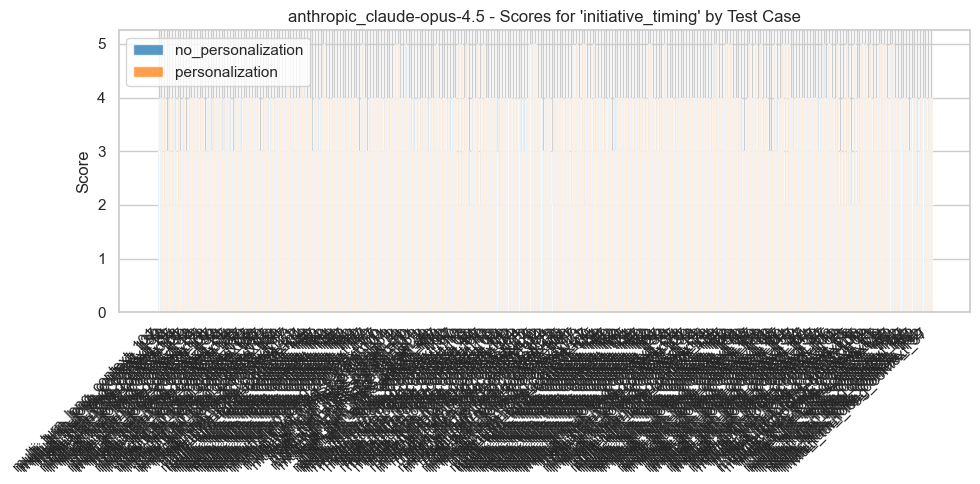

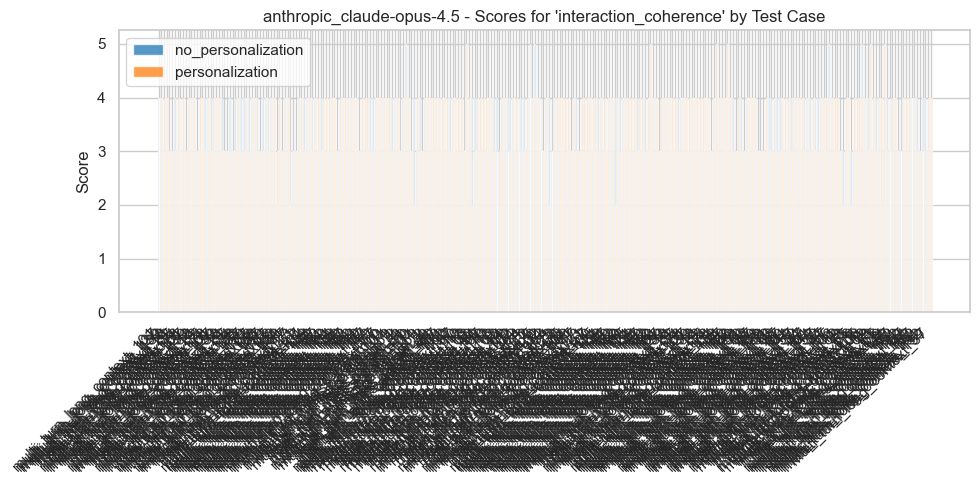

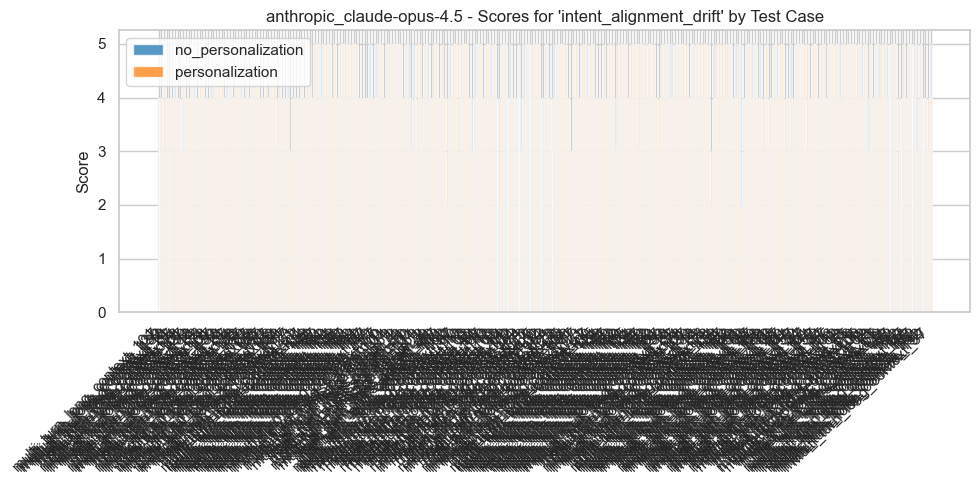

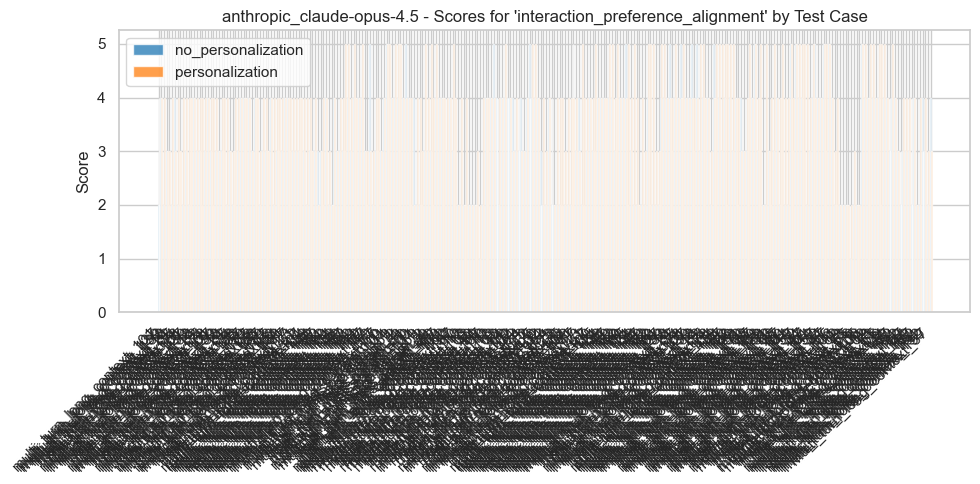

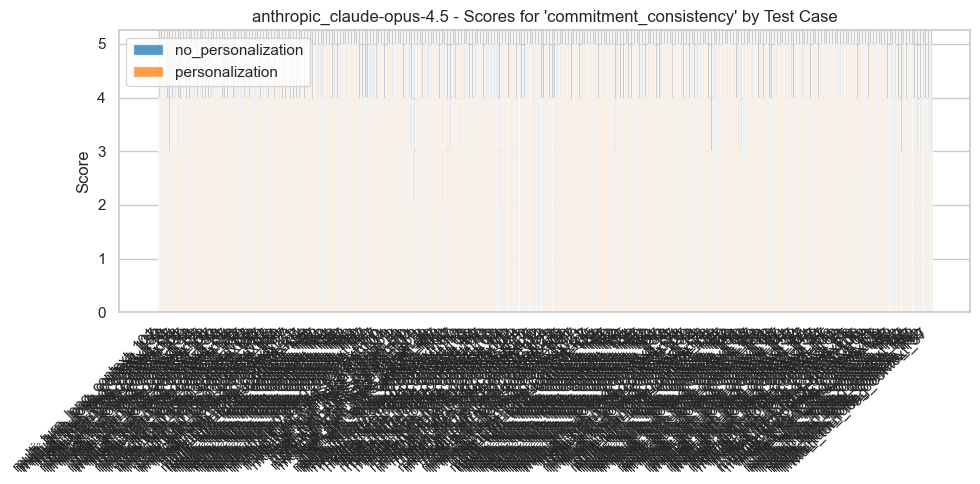

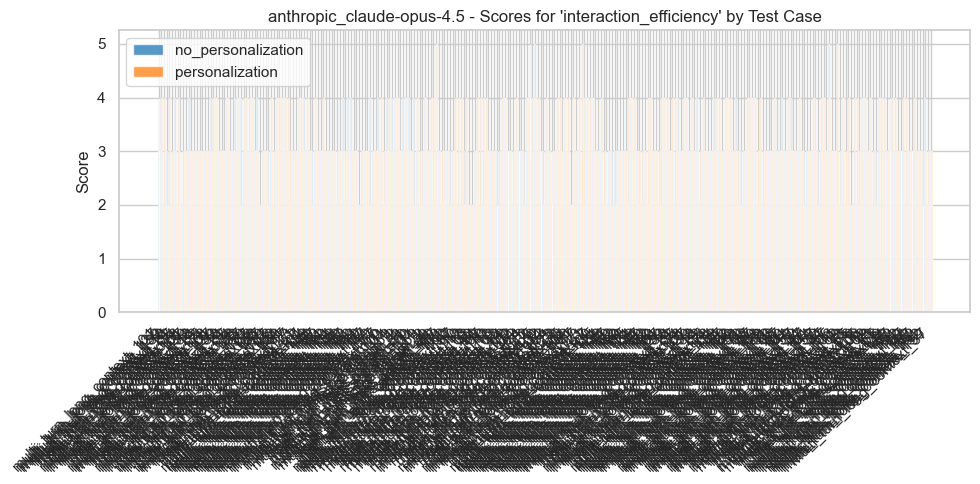

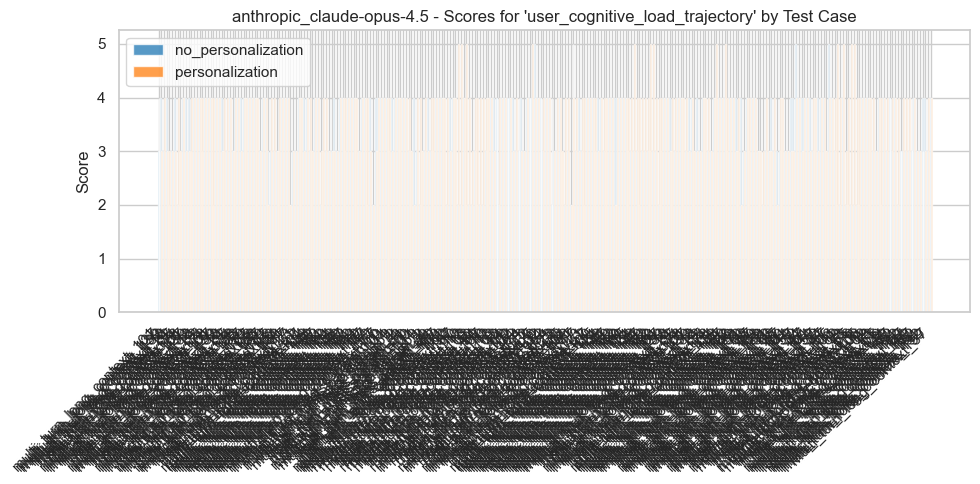

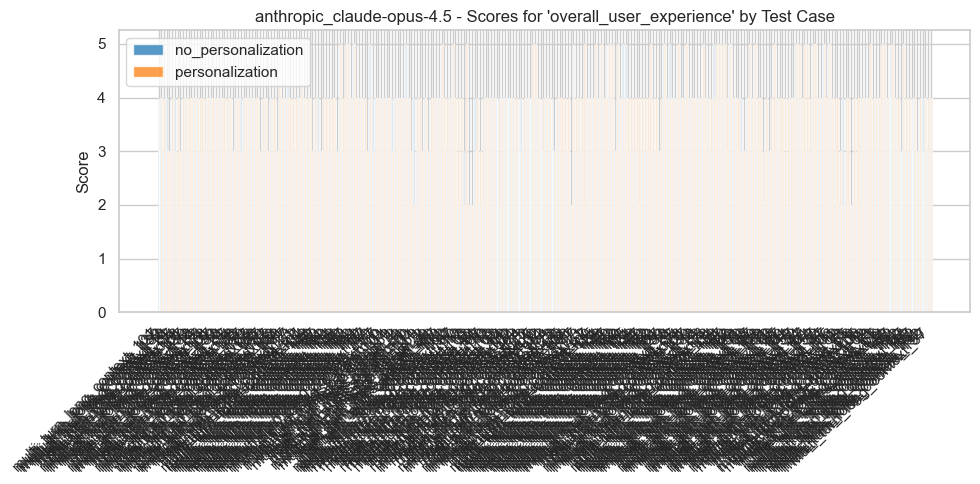

In [30]:
import matplotlib.pyplot as plt

# For each dimension, plot barplot of all testcases: two bars per test_id (no personalization, personalization)
# Show the first judge's barplot as an example
if merged_data:
    first_judge = list(merged_data.keys())[0]
    merged = merged_data[first_judge]
    print(f"Barplot for {first_judge}:")
    
    for dim in DIMENSIONS:
        plt.figure(figsize=(10, 5))
        ids = merged["test_id"]
        width = 0.35
        x = np.arange(len(ids))
        vals_no = merged[f"{dim}_no"]
        vals_p = merged[f"{dim}_p"]
        
        plt.bar(x - width/2, vals_no, width=width, label="no_personalization", color="#1f77b4", alpha=0.75)
        plt.bar(x + width/2, vals_p, width=width, label="personalization", color="#ff7f0e", alpha=0.75)
        
        plt.xticks(x, ids, rotation=45, ha='right')
        plt.ylabel("Score")
        plt.title(f"{first_judge} - Scores for '{dim}' by Test Case")
        plt.legend()
        plt.tight_layout()
        plt.show()


In [31]:
condition_summary

,dimension,condition,mean,std,median
0,initiative_timing,no_personalization,3.617021,0.697322,4.0
1,interaction_coherence,no_personalization,3.602837,0.538608,4.0
2,intent_alignment_drift,no_personalization,4.336879,0.677541,4.0
3,interaction_preference_alignment,no_personalization,3.209220,0.963121,3.0
4,commitment_consistency,no_personalization,4.304965,0.607700,4.0
5,interaction_efficiency,no_personalization,3.028369,0.658298,3.0
6,user_cognitive_load_trajectory,no_personalization,3.432624,0.723819,4.0
7,overall_user_experience,no_personalization,3.542553,0.740273,4.0
8,initiative_timing,personalization,4.007092,0.578333,4.0
9,interaction_coherence,personalization,3.670213,0.566973,4.0


In [32]:
# Show delta summary for all judges
for judge_name in JUDGE_NAMES:
    if judge_name not in delta_summary_data:
        continue
    print(f"\n=== Delta Summary for {judge_name} ===")
    display(delta_summary_data[judge_name])

# 为了向后兼容，保留 delta_summary 为第一个可用的 judge
if delta_summary_data:
    first_judge = list(delta_summary_data.keys())[0]
    delta_summary = delta_summary_data[first_judge]


=== Delta Summary for anthropic_claude-opus-4.5 ===


,dimension,metric,mean,std,median,n_delta_gt_0,n_delta_eq_0,n_delta_lt_0
0,initiative_timing,delta,0.390071,0.895008,0.0,100,154,28
1,interaction_coherence,delta,0.067376,0.767952,0.0,83,136,63
2,intent_alignment_drift,delta,0.180851,0.758760,0.0,84,157,41
3,interaction_preference_alignment,delta,0.719858,0.963514,1.0,160,100,22
4,commitment_consistency,delta,0.191489,0.758486,0.0,91,150,41
5,interaction_efficiency,delta,0.287234,0.868045,0.0,104,134,44
6,user_cognitive_load_trajectory,delta,0.319149,0.918913,0.0,97,145,40
7,overall_user_experience,delta,0.446809,0.804131,0.0,123,137,22



=== Delta Summary for anthropic_claude-sonnet-4.5 ===


,dimension,metric,mean,std,median,n_delta_gt_0,n_delta_eq_0,n_delta_lt_0
0,initiative_timing,delta,0.507092,1.560735,0.0,107,122,53
1,interaction_coherence,delta,0.230496,1.492589,0.0,98,108,76
2,intent_alignment_drift,delta,0.092199,0.961173,0.0,30,233,19
3,interaction_preference_alignment,delta,1.134752,1.810290,1.0,147,111,24
4,commitment_consistency,delta,0.127660,1.066147,0.0,37,217,28
5,interaction_efficiency,delta,0.453901,1.341774,0.0,106,131,45
6,user_cognitive_load_trajectory,delta,0.698582,1.440862,0.0,119,133,30
7,overall_user_experience,delta,0.978723,1.562315,1.0,147,108,27



=== Delta Summary for google_gemini-3-flash-preview ===


,dimension,metric,mean,std,median,n_delta_gt_0,n_delta_eq_0,n_delta_lt_0
0,initiative_timing,delta,0.772059,1.574553,0.0,94,160,18
1,interaction_coherence,delta,0.386029,1.438104,0.0,118,92,62
2,intent_alignment_drift,delta,0.147059,0.888877,0.0,21,244,7
3,interaction_preference_alignment,delta,1.183824,1.744584,0.0,116,139,17
4,commitment_consistency,delta,0.110294,0.644852,0.0,14,255,3
5,interaction_efficiency,delta,0.555147,1.592386,0.0,122,88,62
6,user_cognitive_load_trajectory,delta,0.827206,1.417964,0.0,129,117,26
7,overall_user_experience,delta,0.911765,1.442479,0.0,122,129,21



=== Delta Summary for moonshotai_kimi-k2-0905 ===


,dimension,metric,mean,std,median,n_delta_gt_0,n_delta_eq_0,n_delta_lt_0
0,initiative_timing,delta,0.612100,1.361091,0.0,111,133,37
1,interaction_coherence,delta,0.338078,1.285750,0.0,109,124,48
2,intent_alignment_drift,delta,0.103203,0.736806,0.0,16,260,5
3,interaction_preference_alignment,delta,0.978648,1.504602,0.0,127,138,16
4,commitment_consistency,delta,0.167260,1.090771,0.0,37,224,20
5,interaction_efficiency,delta,0.427046,1.347954,0.0,120,108,53
6,user_cognitive_load_trajectory,delta,0.879004,1.341489,0.0,140,118,23
7,overall_user_experience,delta,0.846975,1.271136,0.0,132,131,18


In [33]:
# Show the first judge's merged data (backward compatibility)
# Use merged_data to access all judges' data
if merged_data:
    first_judge = list(merged_data.keys())[0]
    print(f"Merged data for {first_judge} (first judge, for backward compatibility):")
    merged
else:
    print("No merged data available")

Merged data for anthropic_claude-opus-4.5 (first judge, for backward compatibility):


### Overall PERSONA analysis

#### Visualization
Distribution comparisons, delta distributions, and per-test scatter plots.


anthropic_claude-opus-4.5 - initiative_timing: Ratio: 110.78%
anthropic_claude-sonnet-4.5 - initiative_timing: Ratio: 113.86%
google_gemini-3-flash-preview - initiative_timing: Ratio: 119.98%
moonshotai_kimi-k2-0905 - initiative_timing: Ratio: 115.93%


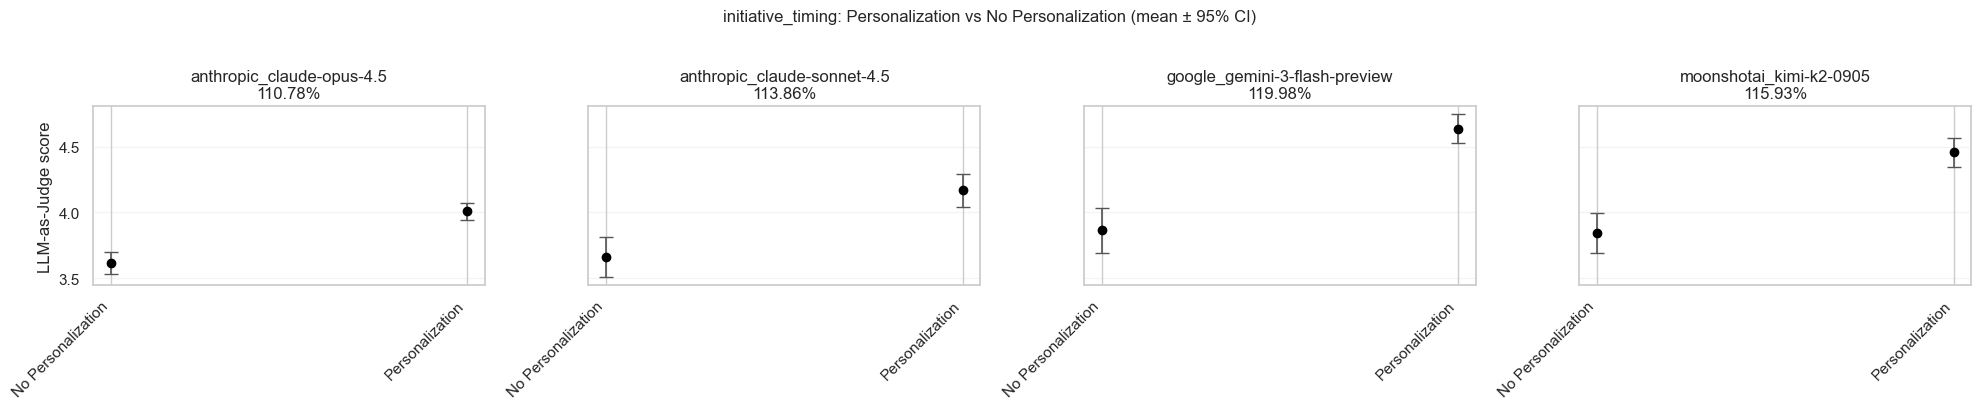

anthropic_claude-opus-4.5 - interaction_coherence: Ratio: 101.87%
anthropic_claude-sonnet-4.5 - interaction_coherence: Ratio: 106.97%
google_gemini-3-flash-preview - interaction_coherence: Ratio: 110.01%
moonshotai_kimi-k2-0905 - interaction_coherence: Ratio: 108.48%


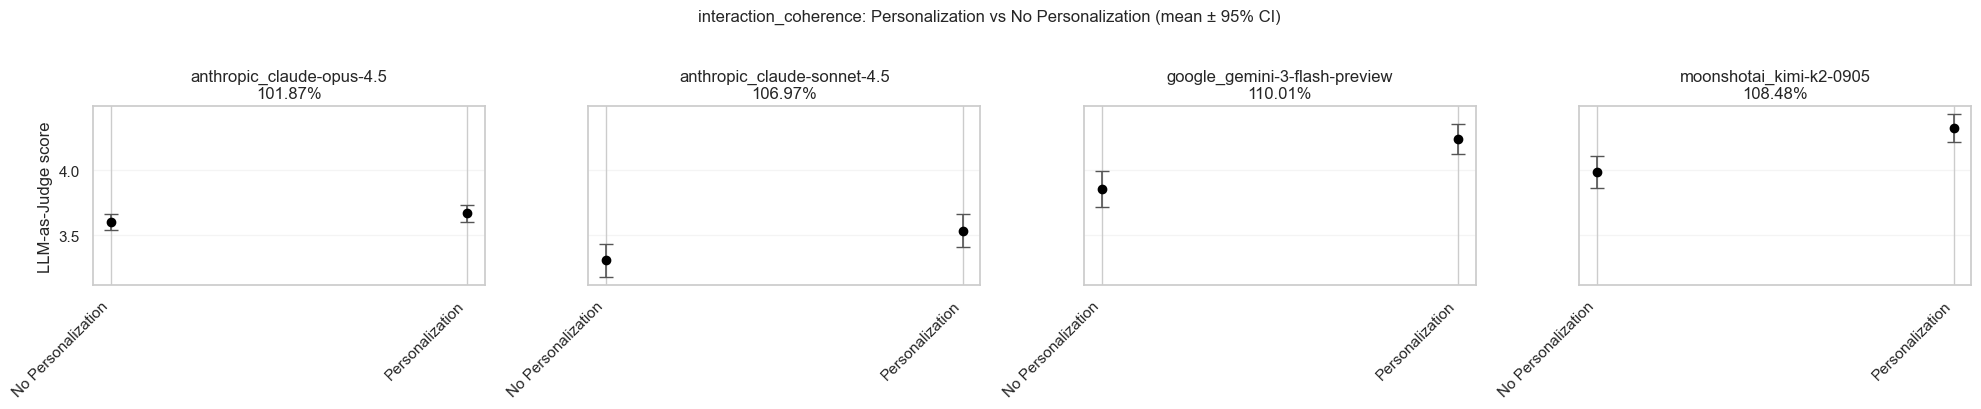

anthropic_claude-opus-4.5 - intent_alignment_drift: Ratio: 104.17%
anthropic_claude-sonnet-4.5 - intent_alignment_drift: Ratio: 101.94%
google_gemini-3-flash-preview - intent_alignment_drift: Ratio: 103.09%
moonshotai_kimi-k2-0905 - intent_alignment_drift: Ratio: 102.13%


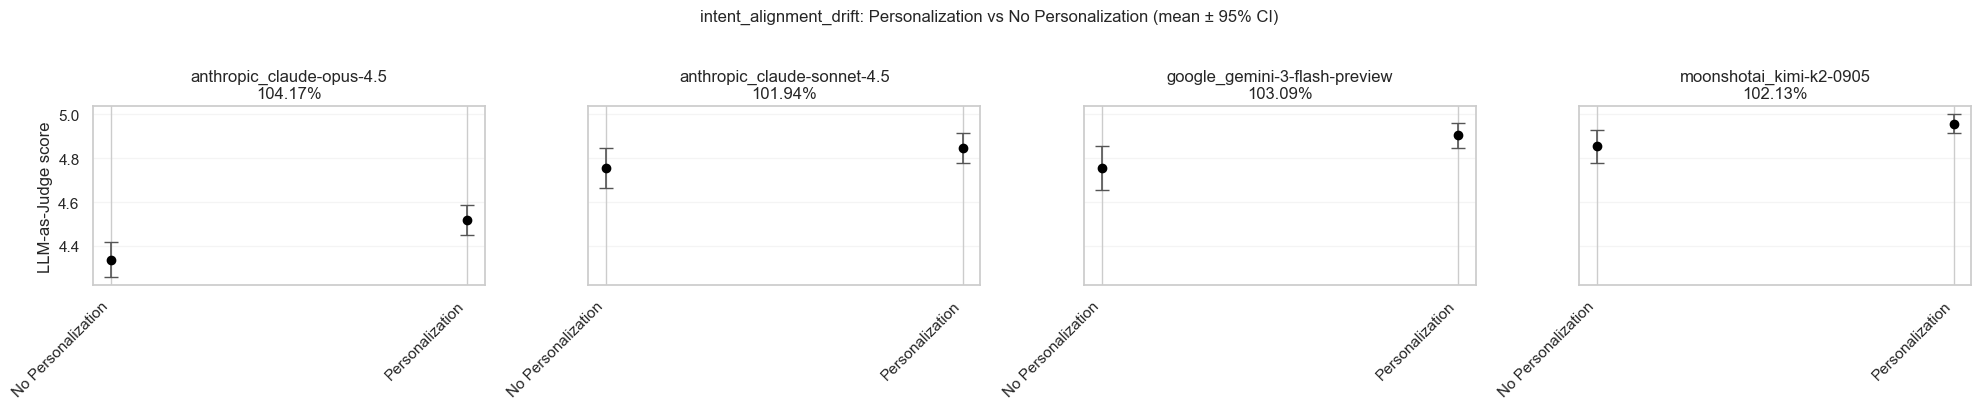

anthropic_claude-opus-4.5 - interaction_preference_alignment: Ratio: 122.43%
anthropic_claude-sonnet-4.5 - interaction_preference_alignment: Ratio: 143.18%
google_gemini-3-flash-preview - interaction_preference_alignment: Ratio: 134.66%
moonshotai_kimi-k2-0905 - interaction_preference_alignment: Ratio: 129.41%


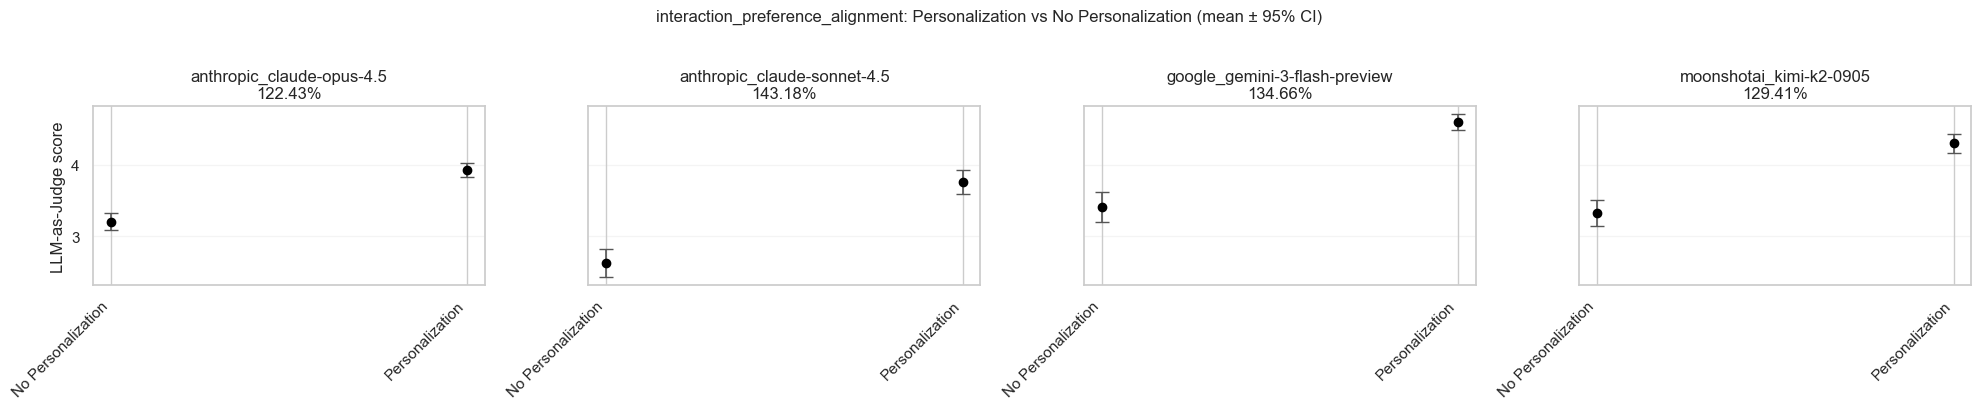

anthropic_claude-opus-4.5 - commitment_consistency: Ratio: 104.45%
anthropic_claude-sonnet-4.5 - commitment_consistency: Ratio: 102.76%
google_gemini-3-flash-preview - commitment_consistency: Ratio: 102.27%
moonshotai_kimi-k2-0905 - commitment_consistency: Ratio: 103.63%


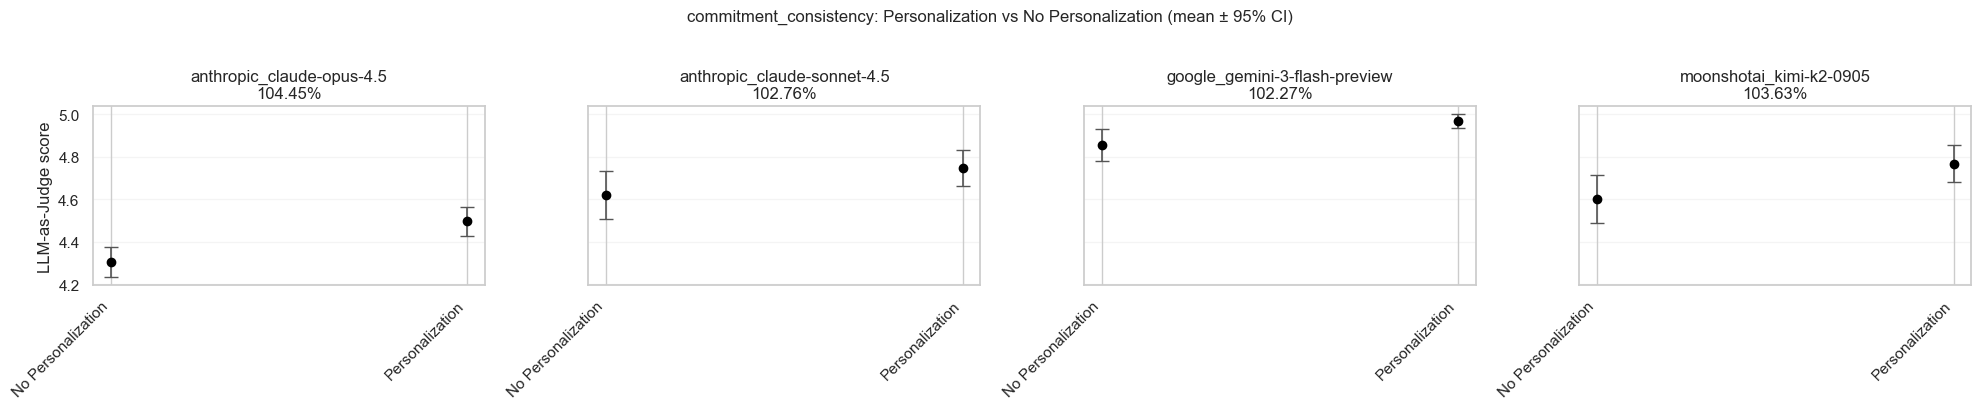

anthropic_claude-opus-4.5 - interaction_efficiency: Ratio: 109.48%
anthropic_claude-sonnet-4.5 - interaction_efficiency: Ratio: 118.88%
google_gemini-3-flash-preview - interaction_efficiency: Ratio: 116.74%
moonshotai_kimi-k2-0905 - interaction_efficiency: Ratio: 113.86%


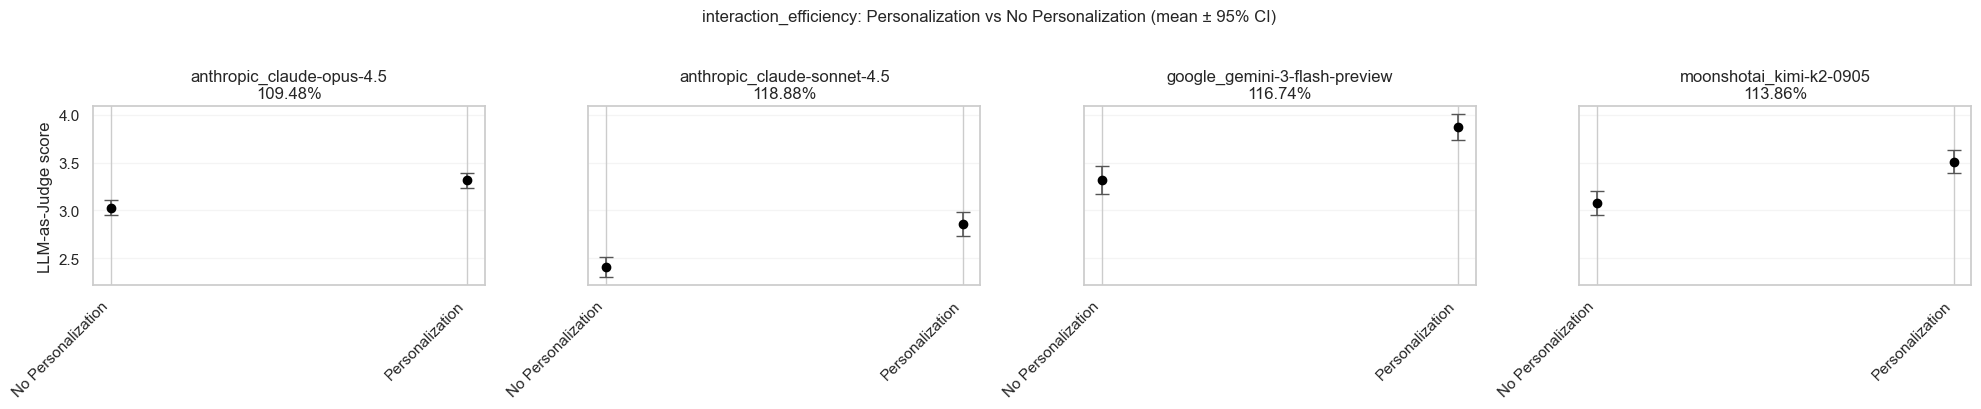

anthropic_claude-opus-4.5 - user_cognitive_load_trajectory: Ratio: 109.30%
anthropic_claude-sonnet-4.5 - user_cognitive_load_trajectory: Ratio: 127.48%
google_gemini-3-flash-preview - user_cognitive_load_trajectory: Ratio: 122.82%
moonshotai_kimi-k2-0905 - user_cognitive_load_trajectory: Ratio: 124.75%


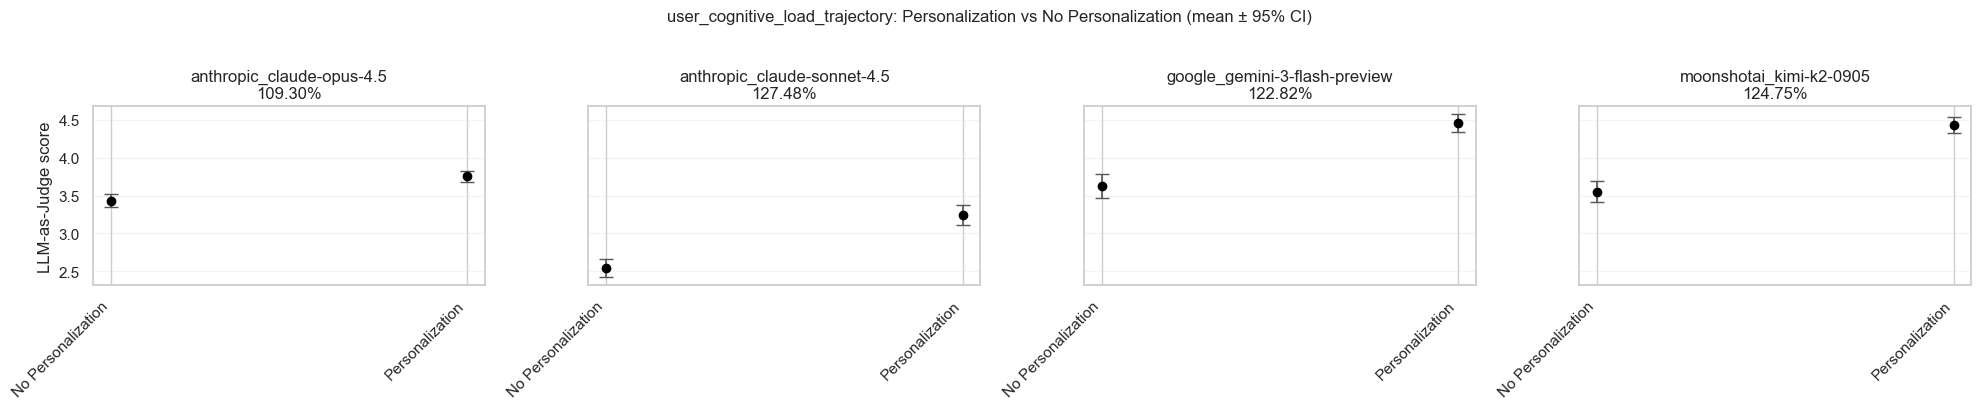

anthropic_claude-opus-4.5 - overall_user_experience: Ratio: 112.61%
anthropic_claude-sonnet-4.5 - overall_user_experience: Ratio: 135.57%
google_gemini-3-flash-preview - overall_user_experience: Ratio: 125.10%
moonshotai_kimi-k2-0905 - overall_user_experience: Ratio: 124.49%


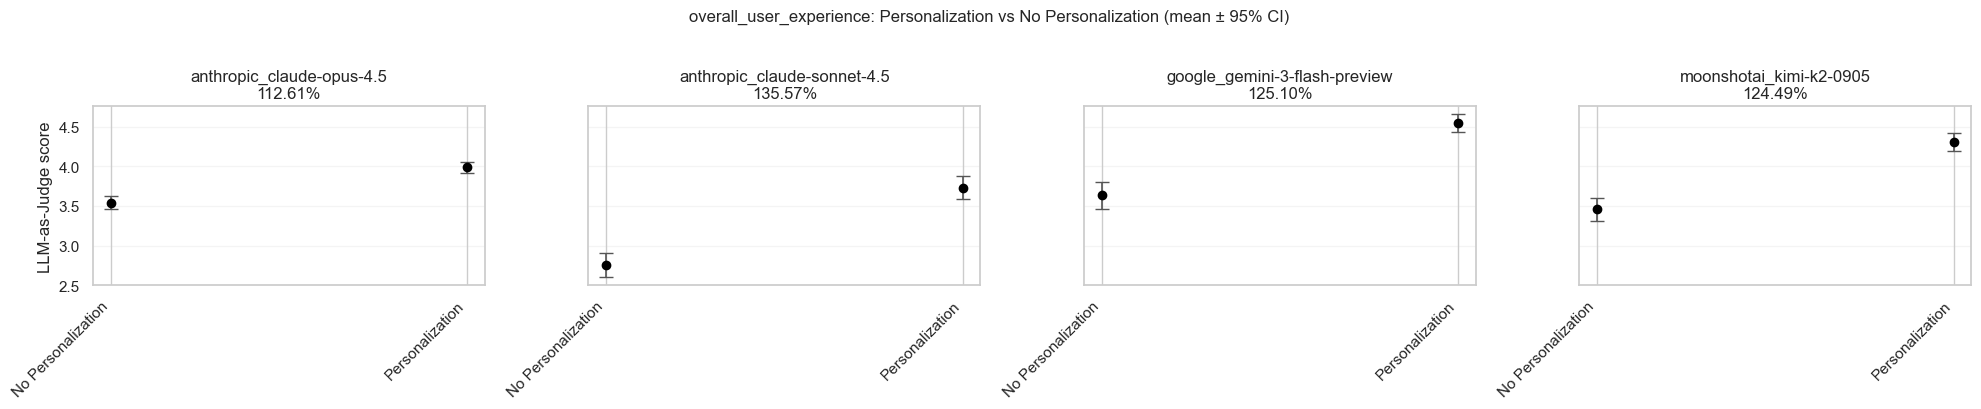

In [34]:
import matplotlib.pyplot as plt
import numpy as np

def plot_condition_errorbar_multimodel(merged_data_dict, dimension, ci=0.95, use_se=False):
    """
    Plot mean score for a dimension under two conditions with error bars for multiple judge models side by side.
    merged_data_dict: dict of {judge_name: merged_dataframe}
    """
    judge_names = list(merged_data_dict.keys())
    n_judges = len(judge_names)
    
    if n_judges == 0:
        raise ValueError("No merged data provided")
    
    fig, axes = plt.subplots(1, n_judges, figsize=(5 * n_judges, 4), sharey=True)
    if n_judges == 1:
        axes = [axes]
    
    z = 1.96 if not use_se else 1.0
    
    all_ratios = []
    
    for idx, judge_name in enumerate(judge_names):
        merged = merged_data_dict[judge_name]
        no_col = f"{dimension}_no"
        p_col = f"{dimension}_p"
        
        if no_col not in merged.columns or p_col not in merged.columns:
            axes[idx].text(0.5, 0.5, f"Missing data\nfor {judge_name}", 
                          ha='center', va='center', transform=axes[idx].transAxes)
            axes[idx].set_title(f"{judge_name}")
            continue
        
        df = merged[[no_col, p_col]].dropna()
        vals = {
            "No Personalization": df[no_col].values,
            "Personalization": df[p_col].values,
        }
        
        means, errs, labels = [], [], []
        for label, arr in vals.items():
            mean = np.mean(arr) if len(arr) else np.nan
            sem = np.std(arr, ddof=1) / np.sqrt(len(arr)) if len(arr) > 1 else 0.0
            err = sem * z if not use_se else sem
            labels.append(label)
            means.append(mean)
            errs.append(err)
        
        # Calculate ratio
        no_mean = means[0]
        p_mean = means[1]
        
        if p_mean >= no_mean:
            ratio = p_mean / no_mean if no_mean != 0 else np.nan
            ratio_text = f"{ratio * 100:.2f}%"
        else:
            ratio = no_mean / p_mean if p_mean != 0 else np.nan
            ratio_text = f"{ratio * 100:.2f}%"
        
        all_ratios.append(ratio_text)
        
        # Print ratio for each judge
        print(f"{judge_name} - {dimension}: Ratio: {ratio_text}")
        
        x = np.arange(len(labels))
        axes[idx].errorbar(
            x, means, yerr=errs, fmt="o", capsize=5, color="black", ecolor="#555",
            elinewidth=1.2, markersize=6,
        )
        axes[idx].set_xticks(x)
        axes[idx].set_xticklabels(labels, rotation=45, ha='right')
        axes[idx].set_ylabel("LLM-as-Judge score" if idx == 0 else "")
        axes[idx].set_title(f"{judge_name}\n{ratio_text}")
        axes[idx].grid(axis="y", alpha=0.2)
    
    fig.suptitle(f"{dimension}: Personalization vs No Personalization (mean ± {'SE' if use_se else '95% CI'})", 
                 fontsize=12, y=1.02)
    plt.tight_layout()
    plt.show()

# Run for all dimensions
for dim in DIMENSIONS:
    plot_condition_errorbar_multimodel(merged_data, dim, ci=0.95, use_se=False)

In [35]:
def mean_across_judges(data_dict, label):
    frames = []
    for judge, df in data_dict.items():
        if target_dim not in df.columns:
            continue
        tmp = df[["test_id", "persona", target_dim]].copy()
        tmp["judge"] = judge
        frames.append(tmp)
    if not frames:
        raise ValueError(f"No data: {label}")
    all_scores = pd.concat(frames, ignore_index=True)
    per_sample = (
        all_scores.groupby(["test_id", "persona"])[target_dim]
        .mean()
        .reset_index(name="mean_score_across_judges")
    )
    overall_mean = per_sample["mean_score_across_judges"].mean()
    return per_sample, overall_mean

# Compute per-sample mean across judges, then global mean and personalization/no_personalization ratio
for target_dim in DIMENSIONS:
    print(f"=== {target_dim} ===")
    no_sample_mean, no_overall_mean = mean_across_judges(no_personalization_data, "no_personalization")
    p_sample_mean, p_overall_mean = mean_across_judges(personalization_data, "personalization")
    ratio = p_overall_mean / no_overall_mean if no_overall_mean else np.nan
    print("No personalization overall mean:", no_overall_mean)
    print("Personalization overall mean:", p_overall_mean)
    print("Personalization / No personalization ratio:", ratio)
    print("\nPer-sample mean across judges (no_personalization):")
    # display(no_sample_mean.head())
    # print("\nPer-sample mean across judges (personalization):")
    # display(p_sample_mean.head())
    # print("\n\n")




=== initiative_timing ===
No personalization overall mean: 3.7449763593380614
Personalization overall mean: 4.319444444444444
Personalization / No personalization ratio: 1.1533969857176674

Per-sample mean across judges (no_personalization):
=== interaction_coherence ===
No personalization overall mean: 3.6835106382978724
Personalization overall mean: 3.9473995271867617
Personalization / No personalization ratio: 1.0716405936622544

Per-sample mean across judges (no_personalization):
=== intent_alignment_drift ===
No personalization overall mean: 4.67434988179669
Personalization overall mean: 4.807624113475177
Personalization / No personalization ratio: 1.0285118219749654

Per-sample mean across judges (no_personalization):
=== interaction_preference_alignment ===
No personalization overall mean: 3.141843971631206
Personalization overall mean: 4.151891252955083
Personalization / No personalization ratio: 1.3214823175319788

Per-sample mean across judges (no_personalization):
=== commit

In [36]:
# Compute overall mean and ratio per dimension and put into a new DataFrame

dim_list = []
no_means = []
p_means = []
ratios = []

for target_dim in DIMENSIONS:
    no_sample_mean, no_overall_mean = mean_across_judges(no_personalization_data, "no_personalization")
    p_sample_mean, p_overall_mean = mean_across_judges(personalization_data, "personalization")
    ratio = 100*(p_overall_mean / no_overall_mean) if no_overall_mean else np.nan

    dim_list.append(target_dim)
    no_means.append(no_overall_mean)
    p_means.append(p_overall_mean)
    ratios.append(ratio)

df_compare = pd.DataFrame({
    "dimension": dim_list,
    "no_personalization": no_means,
    "personalization": p_means,
    "ratio": ratios,
})
display(df_compare)


,dimension,no_personalization,personalization,ratio
0,initiative_timing,3.744976,4.319444,115.339699
1,interaction_coherence,3.683511,3.947400,107.164059
2,intent_alignment_drift,4.674350,4.807624,102.851182
3,interaction_preference_alignment,3.141844,4.151891,132.148232
4,commitment_consistency,4.593085,4.745567,103.319822
5,interaction_efficiency,2.955969,3.393913,114.815555
6,user_cognitive_load_trajectory,3.283097,3.970745,120.945095
7,overall_user_experience,3.343085,4.145390,123.998939


In [37]:
df_compare.to_csv(
    "<PROJECT_ROOT>/Desktop/Desktop - ADUAED19365LPMX/Agent_IX_Personalization/gorilla/berkeley-function-call-leaderboard/bfcl_eval/LLM_as_judge_analysis/compare/df_compare_gemini.csv",
    index=False
)
